<a href="https://www.kaggle.com/code/sonawanelalitsunil/cars-dataset-ml-95-54?scriptVersionId=262072921" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cars-dataset/Price_table.csv
/kaggle/input/cars-dataset/Basic_table.csv
/kaggle/input/cars-dataset/Sales_table.csv
/kaggle/input/cars-dataset/Trim_table.csv
/kaggle/input/cars-dataset/Ad_table (extra).csv
/kaggle/input/cars-dataset/Image_table.csv


## Title: 🚗 Cars Dataset – Analyzing Automotive Trends

## Description:
The Cars Dataset provides detailed insights into various automobile specifications and characteristics, making it valuable for data analysis, machine learning, and predictive modeling. This dataset typically includes attributes such as brand, model, year of manufacture, engine type, fuel efficiency, horsepower, mileage, price, safety features, and performance indicators.

By exploring this dataset, one can analyze patterns like the impact of engine capacity on fuel economy, price comparisons across brands, popularity of fuel types, and trends in vehicle safety and performance. It can be applied in use cases such as:

Predictive modeling: Estimating car prices based on specifications.

Customer insights: Understanding preferences in fuel type, body style, and performance.

Market trends: Comparing cars across regions, brands, or production years.

Sustainability studies: Evaluating the shift from petrol/diesel to electric vehicles.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/cars-dataset/Sales_table.csv")

In [3]:
df.head()

,Maker,Genmodel,Genmodel_ID,2020,2019,2018,2017,2016,2015,2014,...,2010,2009,2008,2007,2006,2005,2004,2003,2002,2001
0,ABARTH,ABARTH 124,2_1,0,19,27,60,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ABARTH,ABARTH 500,2_2,0,0,1,2,66,717,762,...,915,766,0,0,0,0,0,0,0,0
2,ABARTH,ABARTH 595,2_4,2144,2866,3907,3295,3132,1612,516,...,0,0,0,0,0,0,0,0,0,0
3,ABARTH,ABARTH 695,2_6,45,65,270,114,29,10,14,...,0,0,0,0,0,0,0,0,0,0
4,ABARTH,ABARTH PUNTO,2_9,0,0,0,0,0,0,56,...,97,172,74,0,0,0,0,0,0,0


In [4]:
df.tail()

,Maker,Genmodel,Genmodel_ID,2020,2019,2018,2017,2016,2015,2014,...,2010,2009,2008,2007,2006,2005,2004,2003,2002,2001
768,VOLVO,VOLVO XC40,96_20,24281,14894,6616,8,0,0,0,...,0,0,0,0,0,0,0,0,0,0
769,VOLVO,VOLVO XC60,96_16,7694,11182,10840,14994,14808,12830,9102,...,4548,3373,308,0,0,0,0,0,0,0
770,VOLVO,VOLVO XC70,96_17,0,0,0,17,1006,1586,1710,...,1447,1067,1059,1423,1347,1524,963,626,119,0
771,VOLVO,VOLVO XC90,96_18,4969,7495,6475,5564,5254,2756,2319,...,6392,3633,1879,3232,3547,4614,3901,1507,0,0
772,ZENOS,ZENOS E10,99_1,0,0,0,2,10,7,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Maker        773 non-null    object
 1   Genmodel     773 non-null    object
 2   Genmodel_ID  773 non-null    object
 3   2020         773 non-null    int64 
 4   2019         773 non-null    int64 
 5   2018         773 non-null    int64 
 6   2017         773 non-null    int64 
 7   2016         773 non-null    int64 
 8   2015         773 non-null    int64 
 9   2014         773 non-null    int64 
 10  2013         773 non-null    int64 
 11  2012         773 non-null    int64 
 12  2011         773 non-null    int64 
 13  2010         773 non-null    int64 
 14  2009         773 non-null    int64 
 15  2008         773 non-null    int64 
 16  2007         773 non-null    int64 
 17  2006         773 non-null    int64 
 18  2005         773 non-null    int64 
 19  2004         773 non-null    

In [6]:
df.describe()

,2020,2019,2018,2017,2016,2015,2014,2013,2012,2011,2010,2009,2008,2007,2006,2005,2004,2003,2002,2001
count,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000
mean,1979.454075,2818.445019,2862.076326,2963.058215,3203.897801,3132.236740,2915.015524,2628.974127,2314.923674,2131.992238,2165.604140,2041.534282,1941.636481,1976.517464,1626.055627,1325.930142,1058.534282,805.106080,564.614489,349.142303
std,5403.526805,7466.655137,7731.051191,8199.212870,9234.009443,9571.845809,9085.533712,8520.582424,7742.340436,7122.691281,7249.633197,7136.761258,6755.753065,6958.049764,5690.905348,4616.839607,3683.193277,2989.763318,2200.688401,1342.884560
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,794.000000,1440.000000,1427.000000,1437.000000,1392.000000,1287.000000,946.000000,846.000000,684.000000,612.000000,674.000000,602.000000,560.000000,550.000000,480.000000,418.000000,224.000000,106.000000,62.000000,36.000000
max,46739.000000,74500.000000,89564.000000,87409.000000,113568.000000,125619.000000,122815.000000,113390.000000,100228.000000,87266.000000,91353.000000,100975.000000,73429.000000,77257.000000,68079.000000,58824.000000,43404.000000,32345.000000,26767.000000,15737.000000


In [7]:
df.isnull().sum()

Maker          0
Genmodel       0
Genmodel_ID    0
2020           0
2019           0
2018           0
2017           0
2016           0
2015           0
2014           0
2013           0
2012           0
2011           0
2010           0
2009           0
2008           0
2007           0
2006           0
2005           0
2004           0
2003           0
2002           0
2001           0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Maker          object
Genmodel       object
Genmodel_ID    object
2020            int64
2019            int64
2018            int64
2017            int64
2016            int64
2015            int64
2014            int64
2013            int64
2012            int64
2011            int64
2010            int64
2009            int64
2008            int64
2007            int64
2006            int64
2005            int64
2004            int64
2003            int64
2002            int64
2001            int64
dtype: object

In [10]:
df.shape

(773, 23)

In [11]:
df.columns

Index(['Maker', 'Genmodel', 'Genmodel_ID', '2020', '2019', '2018', '2017',
       '2016', '2015', '2014', '2013', '2012', '2011', '2010', '2009', '2008',
       '2007', '2006', '2005', '2004', '2003', '2002', '2001'],
      dtype='object')

## Data visualizations

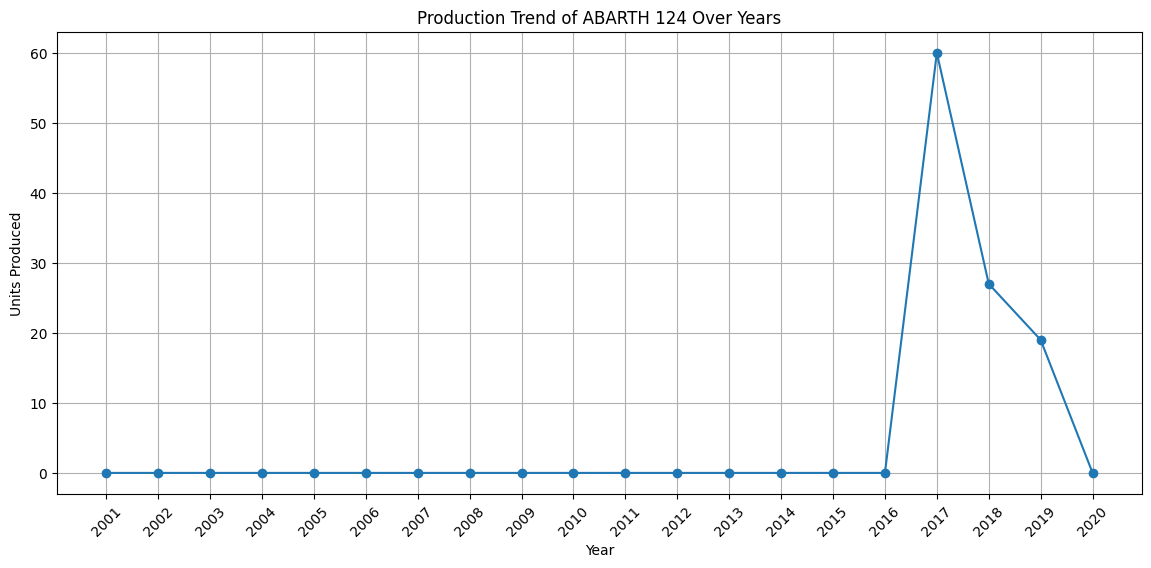

In [12]:
# Choose a valid model from the list
valid_model = df['Genmodel'].unique()[0]  # just pick the first one for testing

# Filter dataset for that model
sample_model = df[df['Genmodel'] == valid_model]

years = [str(y) for y in range(2001, 2021)]

# Plot only if the filtered data exists
if not sample_model.empty:
    plt.figure(figsize=(14,6))
    plt.plot(years, sample_model[years].values.flatten(), marker='o')
    plt.title(f'Production Trend of {valid_model} Over Years')
    plt.xlabel('Year')
    plt.ylabel('Units Produced')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()
else:
    print(f"No data found for model: {valid_model}")

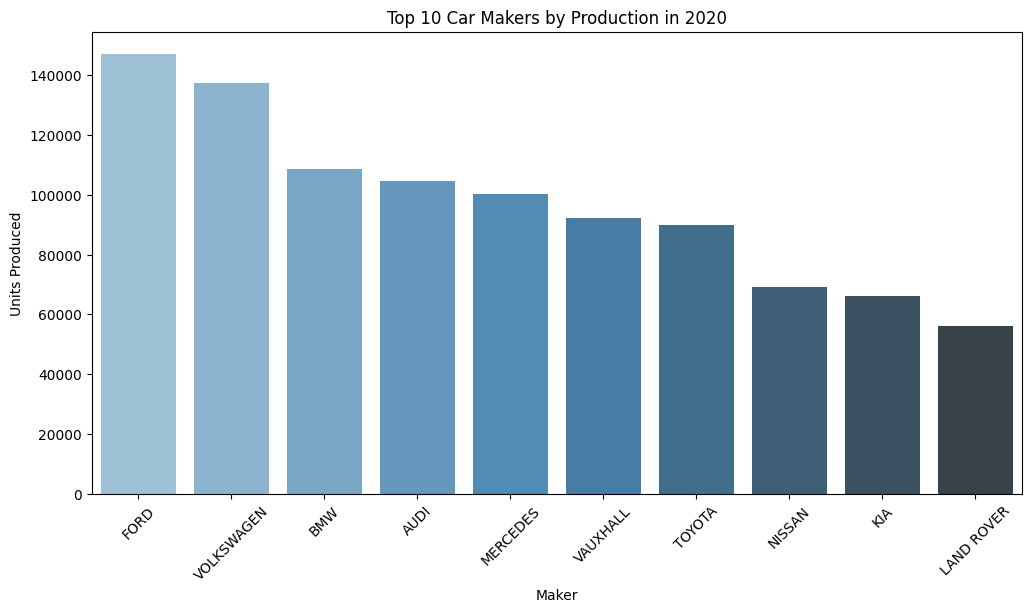

In [13]:
df['Total_2020'] = df['2020']
top_makers = df.groupby('Maker')['Total_2020'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_makers.index, y=top_makers.values, palette='Blues_d')
plt.title('Top 10 Car Makers by Production in 2020')
plt.xlabel('Maker')
plt.ylabel('Units Produced')
plt.xticks(rotation=45)
plt.show()

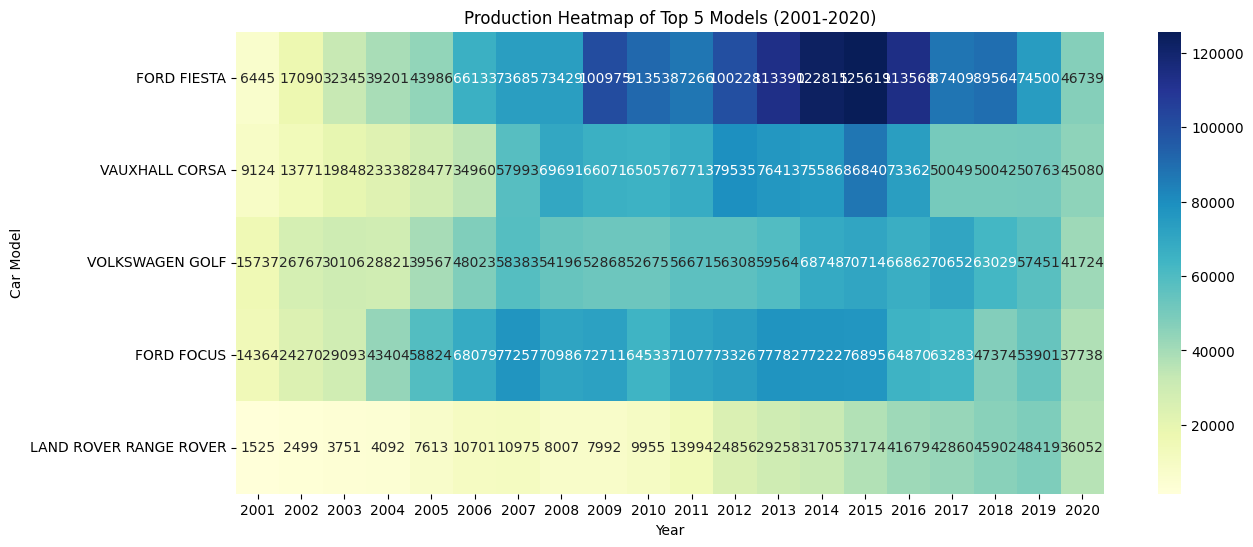

In [14]:
top_models = df.groupby('Genmodel')[years].sum().sort_values(by='2020', ascending=False).head(5)
plt.figure(figsize=(14, 6))
sns.heatmap(top_models, annot=True, fmt='g', cmap='YlGnBu')
plt.title('Production Heatmap of Top 5 Models (2001-2020)')
plt.xlabel('Year')
plt.ylabel('Car Model')
plt.show()


<Figure size 1400x700 with 0 Axes>

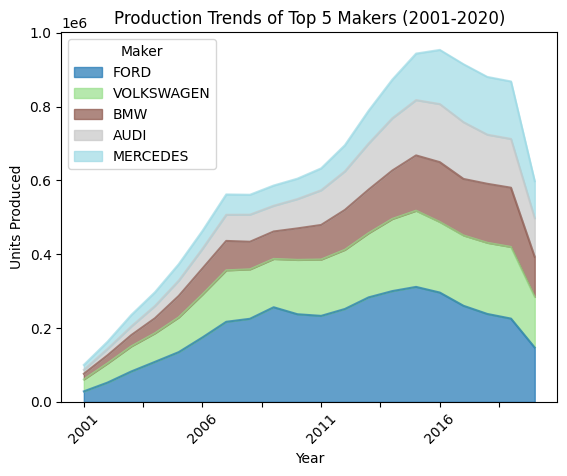

In [15]:
top_makers_overall = df.groupby('Maker')[years].sum().sort_values(by='2020', ascending=False).head(5)
plt.figure(figsize=(14, 7))
top_makers_overall.T.plot(kind='area', stacked=True, cmap='tab20', alpha=0.7)
plt.title('Production Trends of Top 5 Makers (2001-2020)')
plt.xlabel('Year')
plt.ylabel('Units Produced')
plt.xticks(rotation=45)
plt.legend(title='Maker')
plt.show()

## Predictive modeling

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [17]:
years = [str(y) for y in range(2001, 2020)]  # Previous years as features
X = df[years + ['Maker', 'Genmodel']]        # Include categorical features
y = df['2020']

In [18]:
le_maker = LabelEncoder()
le_model = LabelEncoder()
X['Maker'] = le_maker.fit_transform(X['Maker'])
X['Genmodel'] = le_model.fit_transform(X['Genmodel'])


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

In [22]:
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred) * 100  # Convert to percentage
    results[name] = r2
    print(f"{name} R² Accuracy: {r2:.2f}%")

Linear Regression R² Accuracy: 95.19%
Decision Tree R² Accuracy: 85.88%
Random Forest R² Accuracy: 93.54%
Gradient Boosting R² Accuracy: 95.42%


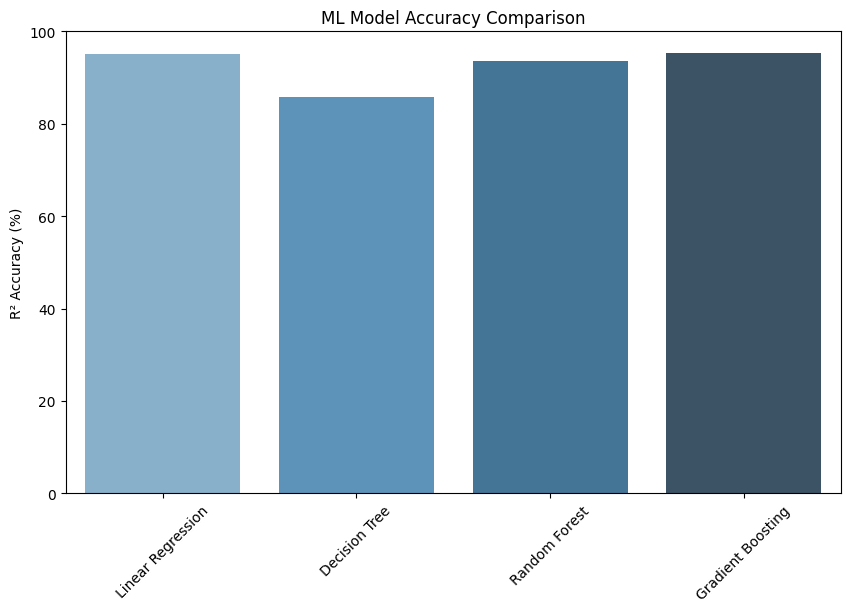

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='Blues_d')
plt.ylabel('R² Accuracy (%)')
plt.title('ML Model Accuracy Comparison')
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.show()

## Thank you..pls upvote!!!